# Advanced Statistics Project

## Superstore Sales Analysis

### Objective

This project applies descriptive and inferential statistical methods to analyze sales performance, profitability, customer behavior, and discount patterns.

The goal is to generate statistical evidence that supports business decisions.

# 1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency
)


# 2. Load Cleaned Dataset

The cleaned dataset prepared during the EDA project is used as the input for this statistical analysis.

In [ ]:

df = pd.read_excel("/content/Cleaned_Superstore.xlsx")
print("✅ Cleaned dataset loaded successfully!")
print(df.head())

✅ Cleaned dataset loaded successfully!
         Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   ...  Discount    Profit Order Day Order Month Order Year Month Name 

# SECTION 1: DESCRIPTIVE STATISTICS

## Objective

Summarize the important characteristics of Sales, Profit, Quantity, and Discount using descriptive statistical measures.

In [ ]:
sales_mean = df['Sales'].mean()
sales_median = df['Sales'].median()
sales_mode = df['Sales'].mode()[0]

#  Mean & Standard Deviation of Profit

In [ ]:
profit_mean = df['Profit'].mean()
profit_std = df['Profit'].std()

#  Range & IQR of Discount

In [ ]:
discount_range = df['Discount'].max() - df['Discount'].min()

discount_iqr = (
    df['Discount'].quantile(0.75)
    - df['Discount'].quantile(0.25)
)

# Distribution Analysis

## Objective

Study the distribution of important numerical variables.

This helps identify skewness, spread, and unusual values before inferential analysis.

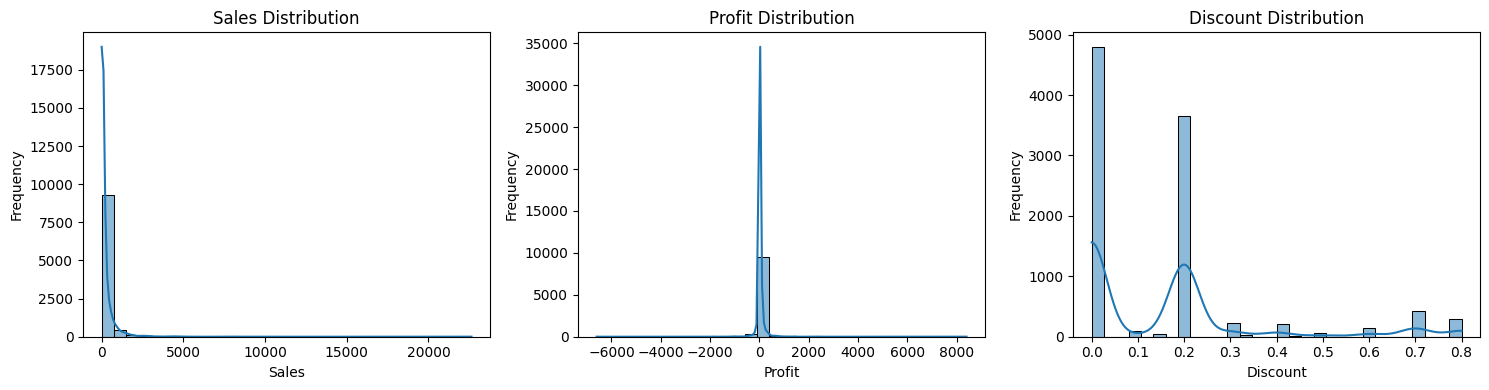

In [ ]:

plt.figure(figsize=(15,4))

# Sales Distribution
plt.subplot(1,3,1)
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

# Profit Distribution
plt.subplot(1,3,2)
sns.histplot(df['Profit'], bins=30, kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

# Discount Distribution
plt.subplot(1,3,3)
sns.histplot(df['Discount'], bins=30, kde=True)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Group Analysis

## Objective

Compare business performance across customer segments and regions.

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].mean()

region_profit = df.groupby('Region')['Profit'].mean()

category_profit_std = (
    df.groupby('Category')['Profit'].std()
)


# Outlier Detection

## Objective

Identify unusually high or low profit values.

Outliers influence averages and business decisions.

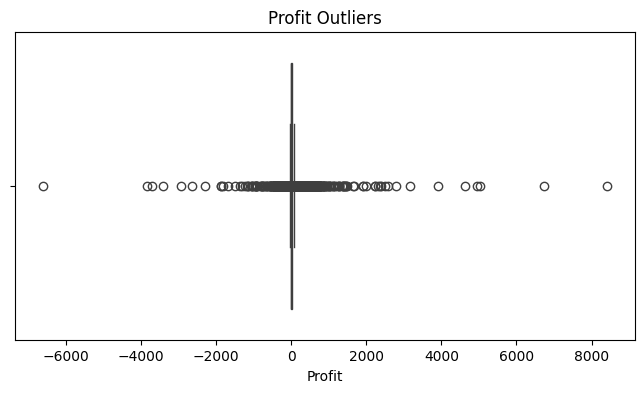

In [ ]:

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Profit'])
plt.title("Profit Outliers")
plt.xlabel("Profit")
plt.show()

mean_vs_median = (
    df['Profit'].mean(),
    df['Profit'].median()
)

# Skewness and Kurtosis

## Objective

Measure the shape of the Sales and Profit distributions.

In [ ]:
sales_skewness = df['Sales'].skew()
profit_skewness = df['Profit'].skew()

sales_kurtosis = df['Sales'].kurt()
profit_kurtosis = df['Profit'].kurt()

# SECTION 2: INFERENTIAL STATISTICS

## Objective

Apply statistical tests to determine whether observed patterns are statistically significant.

# Chi-Square Test

## Business Question

Is Customer Segment associated with Discount Level?

### H0

Customer Segment and Discount Level are independent.

### H1

Customer Segment and Discount Level are associated.

In [ ]:
contingency = pd.crosstab(
    df['Segment'],
    df['Discount Category']
)

chi2, p_val, dof, exp = chi2_contingency(contingency)

# One-Way ANOVA

## Business Question

Does average profit differ across regions?

### H0

Average profit is equal across all regions.

### H1

At least one region has a different average profit.

In [ ]:
anova_region = f_oneway(
    *[
        group["Profit"].values
        for name, group in df.groupby("Region")
    ]
)

anova_category = f_oneway(
    *[
        group["Sales"].values
        for name, group in df.groupby("Category")
    ]
)


# Correlation Analysis

## Objective

Measure the relationship between numerical business variables.

In [ ]:
corr_discount_profit = (
    df['Discount'].corr(df['Profit'])
)

corr_sales_profit = (
    df['Sales'].corr(df['Profit'])
)

corr_quantity_sales = (
    df['Quantity'].corr(df['Sales'])
)

# Correlation Heatmap

The heatmap summarizes the strength of relationships between numerical variables.

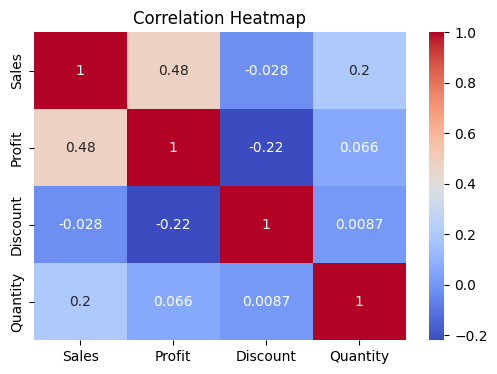

In [ ]:

plt.figure(figsize=(6,4))

corr_matrix = df[
    ['Sales', 'Profit', 'Discount', 'Quantity']
].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Confidence Interval

## Objective

Estimate the range within which the population mean sales value is expected to lie.

In [ ]:
def confidence_interval(series, confidence=0.95):

    mean = np.mean(series)

    sem = stats.sem(series)

    margin = sem * stats.t.ppf(
        (1 + confidence) / 2.,
        len(series) - 1
    )

    return (mean - margin, mean + margin)

ci_sales = confidence_interval(df['Sales'])

ci_profit = confidence_interval(df['Profit'])


# Sampling Validation

Compare the sample mean with the population mean.

In [ ]:
sample = df.sample(
    frac=0.1,
    random_state=42
)

sample_mean = sample['Sales'].mean()

full_mean = df['Sales'].mean()


# Independent T-Test

Compare average profit between high discount and low discount orders.

In [ ]:

high_discount = df[df['Discount'] > 0.3]['Profit']

low_discount = df[df['Discount'] <= 0.3]['Profit']

t_stat, t_pval = ttest_ind(
    high_discount,
    low_discount,
    equal_var=False
)

# Customer Segment Comparison

Compare average profit across customer segments.

In [ ]:

segment_profit = (
    df.groupby('Segment')['Profit'].mean()
)


# SECTION 3: BUSINESS INTERPRETATION

This section converts statistical findings into business insights.

# Pricing & Discount Effectiveness

In [ ]:
pricing_efficiency = df[
    ['Sales', 'Profit', 'Discount']
].describe()

# Weak Regions

In [ ]:
weak_regions = (
    region_profit.sort_values().head()
)

# Loss-Making Products

In [ ]:
loss_products = (
    df[df['Profit'] < 0]
    .groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

# Revenue vs Profitability

In [ ]:

rev_profit_corr = (
    df['Sales'].corr(df['Profit'])
)


# SECTION 4: STRATEGIC RECOMMENDATIONS

Business recommendations based on the statistical analysis.

In [ ]:

recommendations = {

    "Discount Policy":
    "Optimize discounts to balance revenue and profitability.",

    "Segment Focus":
    "Prioritize high-profit customer segments over volume-driven sales.",

    "Actionable Strategy":
    "Reduce focus on loss-making products and strengthen profitable regions."
}

# Discount vs Profit Trend

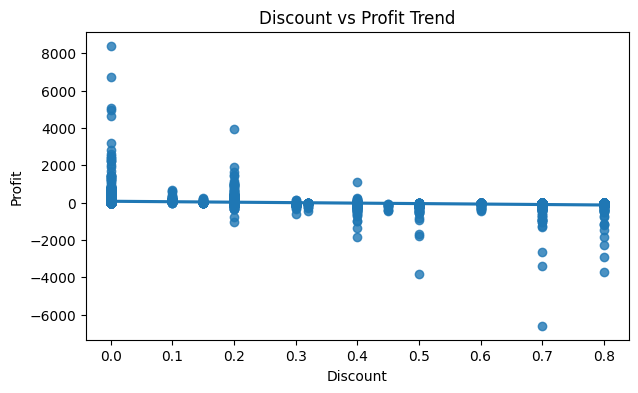

In [ ]:
plt.figure(figsize=(7,4))

sns.regplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title("Discount vs Profit Trend")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

# Profit Variability

In [ ]:
profit_variability = df['Profit'].std()

# FINAL OUTPUTS

In [ ]:
print("\n================ FINAL RESULTS ================\n")


================ FINAL RESULTS ================



# Descriptive Statistics

In [ ]:
print("Sales Mean:", sales_mean)
print("Sales Median:", sales_median)
print("Sales Mode:", sales_mode)

print("\nProfit Mean:", profit_mean)
print("Profit Standard Deviation:", profit_std)

print("\nDiscount Range:", discount_range)
print("Discount IQR:", discount_iqr)

Sales Mean: 229.8528458220755
Sales Median: 54.48
Sales Mode: 12.96

Profit Mean: 28.660970729510655
Profit Standard Deviation: 234.27147564908682

Discount Range: 0.8
Discount IQR: 0.2


# Distribution Interpretation

In [ ]:
if sales_mean > sales_median:
    print("\nSales Distribution is Right-Skewed.")

if profit_mean < sales_mean:
    print("Profit values are much lower than sales values.")


Sales Distribution is Right-Skewed.
Profit values are much lower than sales values.


# Skewness & Kurtosis

In [ ]:

print("\nSales Skewness:", sales_skewness)
print("Profit Skewness:", profit_skewness)

print("\nSales Kurtosis:", sales_kurtosis)
print("Profit Kurtosis:", profit_kurtosis)


Sales Skewness: 12.972141558363266
Profit Skewness: 7.561035996041442

Sales Kurtosis: 305.2817697063499
Profit Kurtosis: 397.15038474389235


# Chi-Square Test

In [ ]:
print("\nChi-Square p-value:", p_val)

if p_val < 0.05:
    print("Decision: Reject the Null Hypothesis")
    print("Business Interpretation: Customer Segment and Discount Level are significantly associated.")
else:
    print("Decision: Fail to Reject the Null Hypothesis")
    print("Business Interpretation: No significant association exists.")


Chi-Square p-value: 0.20474308384111092
Decision: Fail to Reject the Null Hypothesis
Business Interpretation: No significant association exists.


# ANOVA Tests

In [ ]:

print("\nANOVA Region Result:", anova_region)

if anova_region.pvalue < 0.05:
    print(
        "Business Insight: Profit differs significantly "
        "across regions."
    )

else:
    print(
        "Business Insight: Regional profit differences "
        "are not statistically significant."
    )

print("\nANOVA Category Result:", anova_category)

if anova_category.pvalue < 0.05:
    print(
        "Business Insight: Sales differ significantly "
        "across categories."
    )


ANOVA Region Result: F_onewayResult(statistic=np.float64(2.624023117536455), pvalue=np.float64(0.04879016190444752))
Business Insight: Profit differs significantly across regions.

ANOVA Category Result: F_onewayResult(statistic=np.float64(265.46629101956006), pvalue=np.float64(4.6633346857643745e-113))
Business Insight: Sales differ significantly across categories.


# Correlations

In [ ]:
print("\nCorrelation: Discount vs Profit =", corr_discount_profit)

if corr_discount_profit < 0:
    print("Business Interpretation: Higher discounts are associated with lower profits.")
else:
    print("Business Interpretation: Higher discounts are associated with higher profits.")


Correlation: Discount vs Profit = -0.219481000829579
Business Interpretation: Higher discounts are associated with lower profits.


# Confidence Intervals

In [ ]:
print("\n95% Confidence Interval for Sales:", ci_sales)

print("Business Interpretation: The true average sales value is expected to lie within this interval with 95% confidence.")


95% Confidence Interval for Sales: (np.float64(217.63110095070957), np.float64(242.07459069344142))
Business Interpretation: The true average sales value is expected to lie within this interval with 95% confidence.


# Sampling Validation

In [ ]:
print("\nSample Mean Sales:", sample_mean)

print("Full Dataset Mean Sales:", full_mean)


Sample Mean Sales: 271.56218468468467
Full Dataset Mean Sales: 229.8528458220755


# T-Test

In [ ]:
print("\nT-Test Statistic:", t_stat)
print("P-value:", t_pval)

if t_pval < 0.05:
    print("Decision: Reject the Null Hypothesis")
    print("Business Interpretation: Average profit differs significantly between the two discount groups.")
else:
    print("Decision: Fail to Reject the Null Hypothesis")
    print("Business Interpretation: No significant difference in average profit was observed.")


T-Test Statistic: -14.440048883834336
P-value: 7.043625492100404e-44
Decision: Reject the Null Hypothesis
Business Interpretation: Average profit differs significantly between the two discount groups.


# Segment Comparison

In [ ]:
print("\nAverage Profit by Segment:\n")

print(segment_profit)


Average Profit by Segment:

Segment
Consumer       25.836873
Corporate      30.456667
Home Office    33.844409
Name: Profit, dtype: float64


# Weak Regions

In [ ]:
print("\nWeak Performing Regions:\n")

print(weak_regions)


Weak Performing Regions:

Region
Central    17.092709
South      28.857673
East       32.151331
West       33.849032
Name: Profit, dtype: float64


# Loss-Making Products

In [ ]:

print("\nLoss-Making Products:\n")

print(loss_products)


Loss-Making Products:

Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.5272
Ibico EPK-21 Electric Binding System                                          -2929.4845
Bush Advantage Collection Racetrack Conference Table                          -2545.2600
Name: Profit, dtype: float64


# Recommendations

In [ ]:
print("\nStrategic Recommendations:\n")

for key, value in recommendations.items():
    print(f"{key}: {value}")


Strategic Recommendations:

Discount Policy: Optimize discounts to balance revenue and profitability.
Segment Focus: Prioritize high-profit customer segments over volume-driven sales.
Actionable Strategy: Reduce focus on loss-making products and strengthen profitable regions.


# Profit Variability

In [ ]:
print("\nProfit Variability:", profit_variability)

if profit_variability > 200:
    print(
        "Business Insight: High variability in profit "
        "indicates unstable business performance."
    )



Profit Variability: 234.27147564908682
Business Insight: High variability in profit indicates unstable business performance.


# SAVE VISUALS (OPTIONAL)

In [ ]:

# plt.savefig("sales_distribution.png", bbox_inches='tight')

print("\n✅ Advanced Statistics Project Completed Successfully!")


✅ Advanced Statistics Project Completed Successfully!
